<a href="https://colab.research.google.com/github/DhairyaJani2014/bitcoin-sentiment-analysis/blob/main/BitCoinSentimentAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("Libraries loaded!")

Libraries loaded!


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving fear_greed_index.csv to fear_greed_index.csv
Saving historical_data.csv to historical_data.csv


In [ ]:
trader_df = pd.read_csv('historical_data.csv')
sentiment_df = pd.read_csv('fear_greed_index.csv')

print("Trader Data Shape:", trader_df.shape)
print("Sentiment Data Shape:", sentiment_df.shape)

Trader Data Shape: (211224, 16)
Sentiment Data Shape: (2644, 4)


In [ ]:
print("--- Trader Data ---")
print(trader_df.head())

print("\n--- Sentiment Data ---")
print(sentiment_df.head())

--- Trader Data ---
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0  

In [ ]:
trader_df['date'] = pd.to_datetime(trader_df['time']).dt.date
sentiment_df['date'] = pd.to_datetime(sentiment_df['Date']).dt.date

print("Trader dates:", trader_df['date'].min(), "to", trader_df['date'].max())
print("Sentiment dates:", sentiment_df['date'].min(), "to", sentiment_df['date'].max())

KeyError: 'time'

In [ ]:
print("Trader columns:", trader_df.columns.tolist())
print("Sentiment columns:", sentiment_df.columns.tolist())

Trader columns: ['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']
Sentiment columns: ['timestamp', 'value', 'classification', 'date']


In [ ]:
trader_df['date'] = pd.to_datetime(trader_df['Timestamp IST']).dt.date
sentiment_df['date'] = pd.to_datetime(sentiment_df['date']).dt.date

print("Trader dates:", trader_df['date'].min(), "to", trader_df['date'].max())
print("Sentiment dates:", sentiment_df['date'].min(), "to", sentiment_df['date'].max())

ValueError: time data "18-03-2025 12:50" doesn't match format "%m-%d-%Y %H:%M", at position 18. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [ ]:
print("Trader timestamp sample:")
print(trader_df['Timestamp IST'].head())

print("\nSentiment date sample:")
print(sentiment_df['date'].head())

Trader timestamp sample:
0    02-12-2024 22:50
1    02-12-2024 22:50
2    02-12-2024 22:50
3    02-12-2024 22:50
4    02-12-2024 22:50
Name: Timestamp IST, dtype: object

Sentiment date sample:
0    2018-02-01
1    2018-02-02
2    2018-02-03
3    2018-02-04
4    2018-02-05
Name: date, dtype: object


In [ ]:
trader_df['date'] = pd.to_datetime(trader_df['Timestamp IST'], format='%d-%m-%Y %H:%M').dt.date
sentiment_df['date'] = pd.to_datetime(sentiment_df['date']).dt.date

print("Trader dates:", trader_df['date'].min(), "to", trader_df['date'].max())
print("Sentiment dates:", sentiment_df['date'].min(), "to", sentiment_df['date'].max())

Trader dates: 2023-05-01 to 2025-05-01
Sentiment dates: 2018-02-01 to 2025-05-02


In [ ]:
merged_df = pd.merge(trader_df, sentiment_df, on='date', how='inner')

print("Merged Shape:", merged_df.shape)
print(merged_df.head())

Merged Shape: (211218, 20)
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID

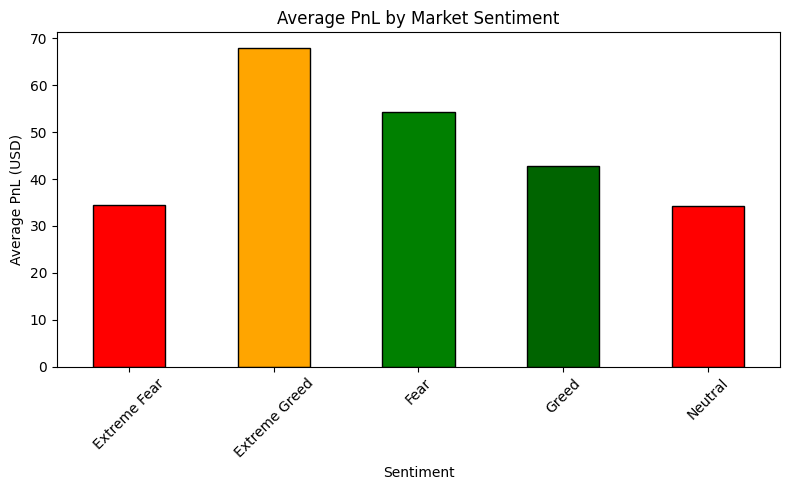

In [ ]:
pnl_by_sentiment = merged_df.groupby('classification')['Closed PnL'].mean()

plt.figure(figsize=(8,5))
pnl_by_sentiment.plot(kind='bar', color=['red','orange','green','darkgreen'], edgecolor='black')
plt.title('Average PnL by Market Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Average PnL (USD)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

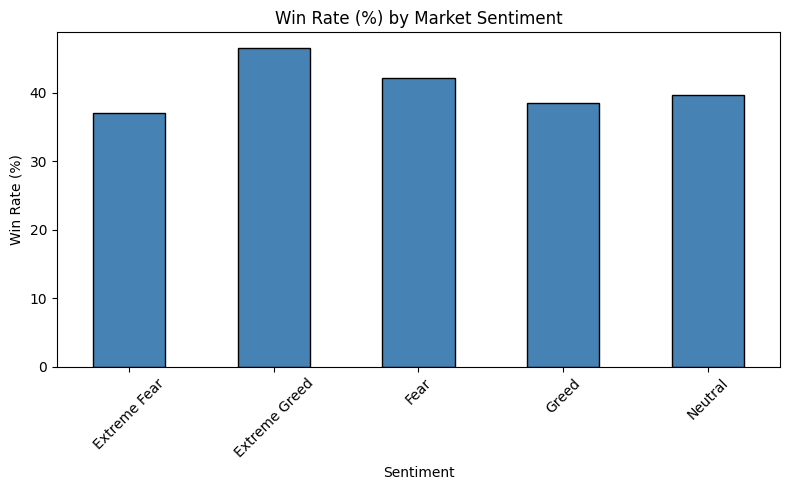

In [ ]:
merged_df['is_win'] = merged_df['Closed PnL'] > 0
win_rate = merged_df.groupby('classification')['is_win'].mean() * 100

plt.figure(figsize=(8,5))
win_rate.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Win Rate (%) by Market Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Win Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

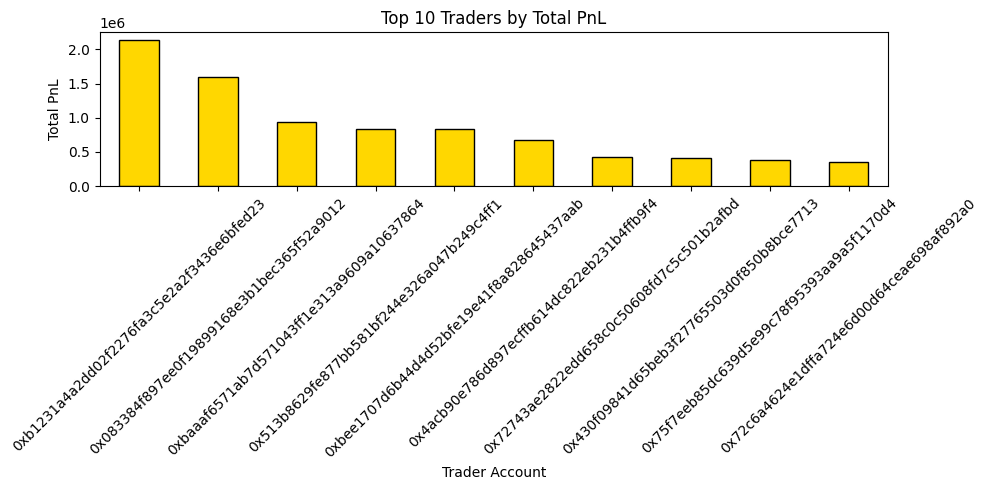

In [ ]:
top_traders = merged_df.groupby('Account')['Closed PnL'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_traders.plot(kind='bar', color='gold', edgecolor='black')
plt.title('Top 10 Traders by Total PnL')
plt.xlabel('Trader Account')
plt.ylabel('Total PnL')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
print("=" * 50)
print(" KEY INSIGHTS SUMMARY")
print("=" * 50)

print("\n1. Average PnL by Sentiment:")
print(merged_df.groupby('classification')['Closed PnL'].mean().round(2))

print("\n2. Win Rate by Sentiment (%):")
print(win_rate.round(2))

print("\n3. Total Trades by Sentiment:")
print(merged_df['classification'].value_counts())

print("\n4. Best Sentiment for Trading:")
best = merged_df.groupby('classification')['Closed PnL'].mean().idxmax()
worst = merged_df.groupby('classification')['Closed PnL'].mean().idxmin()
print(f"   Best  → {best}")
print(f"   Worst → {worst}")

 KEY INSIGHTS SUMMARY

1. Average PnL by Sentiment:
classification
Extreme Fear     34.54
Extreme Greed    67.89
Fear             54.29
Greed            42.74
Neutral          34.31
Name: Closed PnL, dtype: float64

2. Win Rate by Sentiment (%):
classification
Extreme Fear     37.06
Extreme Greed    46.49
Fear             42.08
Greed            38.48
Neutral          39.70
Name: is_win, dtype: float64

3. Total Trades by Sentiment:
classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64

4. Best Sentiment for Trading:
   Best  → Extreme Greed
   Worst → Neutral


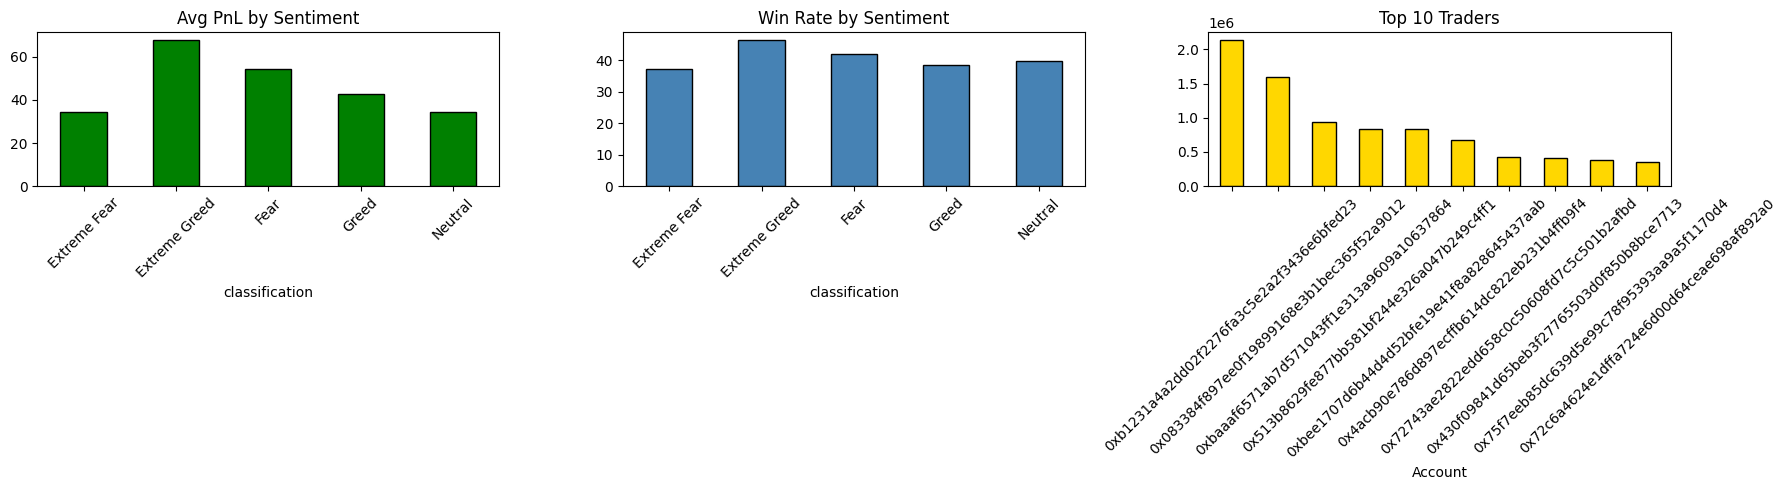

Charts saved! 


In [ ]:
# Save all charts together!!!
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

merged_df.groupby('classification')['Closed PnL'].mean().plot(kind='bar', ax=axes[0], color='green', edgecolor='black')
axes[0].set_title('Avg PnL by Sentiment')
axes[0].tick_params(axis='x', rotation=45)

win_rate.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title('Win Rate by Sentiment')
axes[1].tick_params(axis='x', rotation=45)

top_traders.plot(kind='bar', ax=axes[2], color='gold', edgecolor='black')
axes[2].set_title('Top 10 Traders')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('analysis_results.png', dpi=150)
plt.show()
print("Charts saved! ")

In [ ]:
print("=" * 50)
print("📊 KEY INSIGHTS SUMMARY")
print("=" * 50)

print("\n1. Average PnL by Sentiment:")
print(merged_df.groupby('classification')['Closed PnL'].mean().round(2))

print("\n2. Win Rate by Sentiment (%):")
print(win_rate.round(2))

print("\n3. Total Trades by Sentiment:")
print(merged_df['classification'].value_counts())

print("\n4. Best Sentiment for Trading:")
best = merged_df.groupby('classification')['Closed PnL'].mean().idxmax()
worst = merged_df.groupby('classification')['Closed PnL'].mean().idxmin()
print(f"   Best  → {best}")
print(f"   Worst → {worst}")

📊 KEY INSIGHTS SUMMARY

1. Average PnL by Sentiment:
classification
Extreme Fear     34.54
Extreme Greed    67.89
Fear             54.29
Greed            42.74
Neutral          34.31
Name: Closed PnL, dtype: float64

2. Win Rate by Sentiment (%):
classification
Extreme Fear     37.06
Extreme Greed    46.49
Fear             42.08
Greed            38.48
Neutral          39.70
Name: is_win, dtype: float64

3. Total Trades by Sentiment:
classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64

4. Best Sentiment for Trading:
   Best  → Extreme Greed
   Worst → Neutral
